1. Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# Las columnas están anonimizadas por privacidad
columnas = ['A1','A2','A3','A4','A5','A6','A7',
            'A8','A9','A10','A11','A12','A13','A14','A15','A16']

df = pd.read_csv('data/crx.data', names=columnas, na_values='?')

print("✅ Dataset cargado")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

✅ Dataset cargado
Filas: 690, Columnas: 16


2. Vista general

In [2]:
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE VARIABLES ===")
print(df.dtypes)

numericas   = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()
print(f"\nNuméricas: {numericas}")
print(f"Categóricas: {categoricas}")

=== PRIMERAS FILAS ===


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+



=== TIPOS DE VARIABLES ===
A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

Numéricas: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categóricas: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A16']


C:\Users\Natalia\AppData\Local\Temp\ipykernel_22088\417939683.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


3. Valores nulos

In [3]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)

print("=== VALORES NULOS ===")
print(missing[missing['Valores nulos'] > 0])

=== VALORES NULOS ===
     Valores nulos  Porcentaje (%)
A14             13            1.88
A1              12            1.74
A2              12            1.74
A7               9            1.30
A6               9            1.30
A5               6            0.87
A4               6            0.87


4. Imputación

In [4]:
# KNN para numéricas
imputer = KNNImputer(n_neighbors=5)
df_num = pd.DataFrame(
    imputer.fit_transform(df[numericas]),
    columns=numericas
)

# Moda para categóricas
df_cat = df[categoricas].fillna(df[categoricas].mode().iloc[0])

df_limpio = pd.concat([df_num, df_cat], axis=1)

print(f"✅ Imputación completada")
print(f"Nulos restantes: {df_limpio.isnull().sum().sum()}")

✅ Imputación completada
Nulos restantes: 0


5. Estadísticas descriptivas

In [5]:
df_limpio.describe().round(2)

,A2,A3,A8,A11,A14,A15
count,690.00,690.00,690.00,690.00,690.00,690.00
mean,31.64,4.76,2.22,2.40,184.99,1017.39
std,11.89,4.98,3.35,4.86,173.31,5210.10
min,13.75,0.00,0.00,0.00,0.00,0.00
25%,22.67,1.00,0.16,0.00,77.00,0.00
50%,28.58,2.75,1.00,0.00,160.00,5.00
75%,38.31,7.21,2.62,3.00,280.00,395.50
max,80.25,28.00,28.50,67.00,2000.00,100000.00


6. Variable objetivo (A16 = aprobado/rechazado)

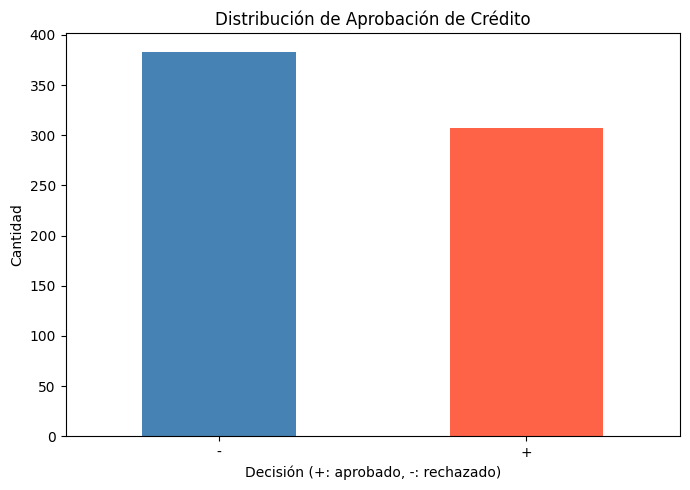

In [6]:
plt.figure(figsize=(7, 5))
df_limpio['A16'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribución de Aprobación de Crédito')
plt.xlabel('Decisión (+: aprobado, -: rechazado)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

7. Correlaciones numéricas

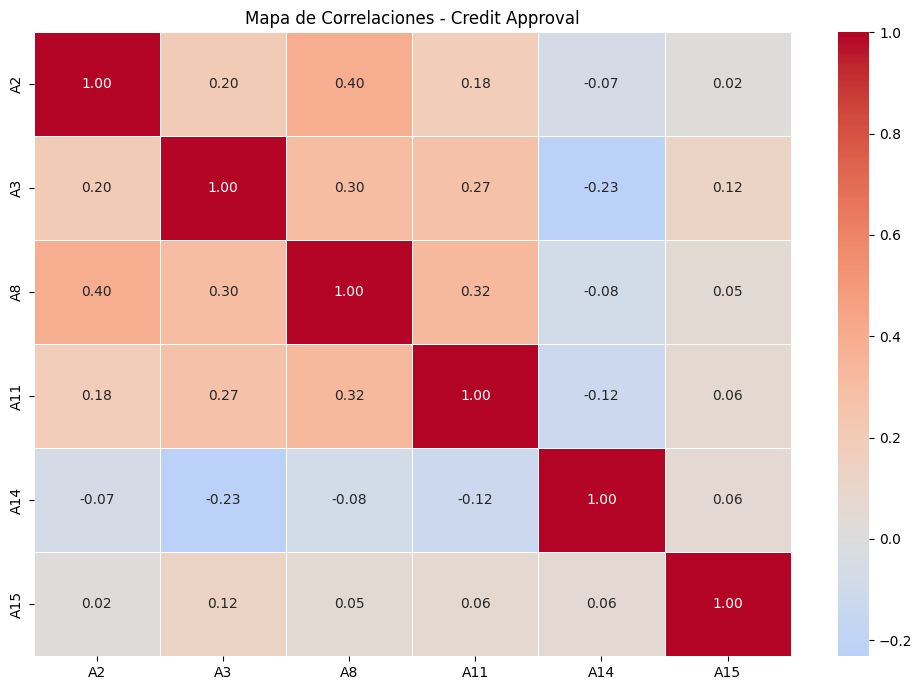

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_num.corr(), cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Mapa de Correlaciones - Credit Approval')
plt.tight_layout()
plt.show()

8. Distribución de A2 y A3 por decisión

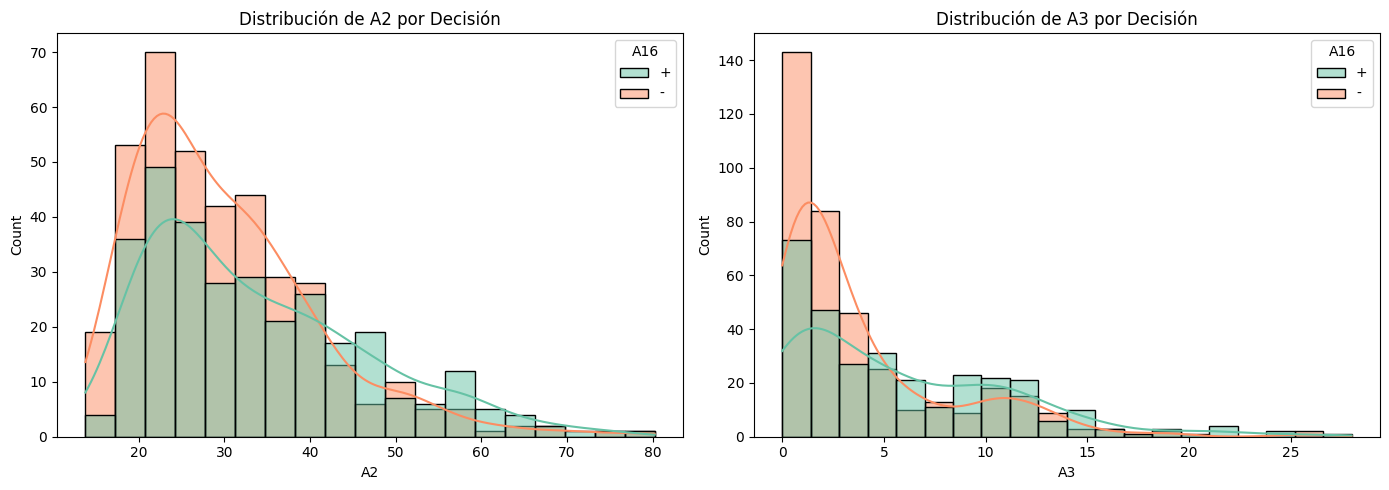

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_limpio, x='A2', hue='A16',
             kde=True, palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de A2 por Decisión')

sns.histplot(data=df_limpio, x='A3', hue='A16',
             kde=True, palette='Set2', ax=axes[1])
axes[1].set_title('Distribución de A3 por Decisión')

plt.tight_layout()
plt.show()